# Task 2 — 03 Approach 1: HOG + Ridge regression

**Goal.** Multi-output linear regression from HOG features (W09_L17) to the 10 landmark coordinates (W09_L18). HOG cell/block parameters are taken verbatim from the W09_L17 slides: **6×6 pixel cells, 0-180° orientation histograms (9 bins), 3×3 block normalisation (L2-Hys)**. Ridge regularisation is added because the HOG dimensionality is comparable to the training-set size; an unregularised `LinearRegression` is reported alongside as a sanity check.

Predictions are produced in the 64×64 pre-processed frame, then **scaled back to the original image resolution** before any NME is computed — the brief and the report reason in original resolution, and we do not let the 64×64 frame leak into the metric.

A second model is trained on **flattened raw 64×64 grayscale pixels** under the same Ridge(α) — the headline HOG-vs-raw ablation. Lecture story: HOG is approximately invariant to brightness and small rotations (W09_L17), so if the assignment's variability hits those axes the HOG model should win materially.

Outputs: `models/hog_ridge.joblib`, `models/raw_ridge.joblib`, `results/hog_linreg_metrics.json`, `results/ced_hog_linreg.npz`, `results/timings_task2.csv`, plus four figures.

In [1]:
import json
import sys
import time
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import joblib
from skimage.feature import hog
from sklearn.linear_model import Ridge, LinearRegression

NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR / 'src'))
from preprocess_img import load_data, preprocess_image, DEFAULT_CONFIG  # noqa: E402
from landmarks import nme, per_landmark_euclidean, ced_curve  # noqa: E402

FIG_DIR = NB_DIR / 'figures'
MODELS_DIR = NB_DIR / 'models'
RESULTS_DIR = NB_DIR / 'results'
for d in (FIG_DIR, MODELS_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams['font.size'] = 11
plt.rcParams['savefig.dpi'] = 150

SEED = 42
np.random.seed(SEED)

## 1. Load data + split, preprocess to 64×64 grayscale

Apply `preprocess_image` with `DEFAULT_CONFIG` (`out_size=(64, 64)`, `grayscale=True`, `hist_eq=False`, `normalise=True`). Histogram equalisation is left off here because W06_L12 explicitly flags it can amplify noise — we revisit this trade-off in 06.

In [2]:
data = load_data()
train_images = data['train_images']
train_points = data['train_points']

split = np.load(NB_DIR / 'data' / 'split_indices.npz')
train_idx = split['train_idx']
val_idx = split['val_idx']

H_orig, W_orig = train_images.shape[1], train_images.shape[2]
H_out, W_out = DEFAULT_CONFIG['out_size']
scale_x_back = W_orig / W_out
scale_y_back = H_orig / H_out
print(f'original res = {H_orig}x{W_orig}, working res = {H_out}x{W_out}')
print(f'pred scale-back factor: x×{scale_x_back:.4f}, y×{scale_y_back:.4f}')

original res = 256x256, working res = 64x64
pred scale-back factor: x×4.0000, y×4.0000


In [3]:
def preprocess_split(idxs):
    imgs = np.empty((len(idxs), H_out, W_out), dtype=np.float32)
    lms = np.empty((len(idxs), 5, 2), dtype=np.float32)
    for j, i in enumerate(idxs):
        out, scaled_lm = preprocess_image(train_images[i], train_points[i], DEFAULT_CONFIG)
        imgs[j] = out
        lms[j] = scaled_lm
    return imgs, lms

X_train_img, y_train_lm = preprocess_split(train_idx)
X_val_img, y_val_lm = preprocess_split(val_idx)

assert (y_train_lm >= 0).all() and (y_train_lm <= W_out).all(), 'scaled train landmarks out of [0, 64]'
assert (y_val_lm >= 0).all() and (y_val_lm <= W_out).all(), 'scaled val landmarks out of [0, 64]'
print(f'X_train_img {X_train_img.shape} {X_train_img.dtype}  range [{X_train_img.min():.3f}, {X_train_img.max():.3f}]')
print(f'y_train_lm  {y_train_lm.shape}  range [{y_train_lm.min():.2f}, {y_train_lm.max():.2f}]')
print(f'X_val_img   {X_val_img.shape}')
print(f'y_val_lm    {y_val_lm.shape}')

# Original-resolution GT for val (the frame in which we score NME).
y_val_orig = train_points[val_idx].astype(np.float64)

X_train_img (2210, 64, 64) float32  range [0.000, 1.000]
y_train_lm  (2210, 5, 2)  range [12.22, 52.66]
X_val_img   (390, 64, 64)
y_val_lm    (390, 5, 2)


## 2. HOG features (W09_L17)

`skimage.feature.hog` with the W09_L17 slide parameters: 9 orientation bins over 0-180°, 6×6 pixel cells, 3×3 block normalisation (L2-Hys). On a 64×64 image with 6×6 cells we get ⌊64/6⌋ = 10 cells per side; with 3×3 blocks this gives (10-3+1) = 8 blocks per side, hence 8×8×3×3×9 = 5184 features.

In [4]:
HOG_KW = dict(
    orientations=9,
    pixels_per_cell=(6, 6),
    cells_per_block=(3, 3),
    block_norm='L2-Hys',
    feature_vector=True,
)

sample_feat = hog(X_train_img[0], **HOG_KW)
print(f'HOG vector length per image = {sample_feat.shape[0]}')

HOG vector length per image = 5184


In [5]:
def hog_batch(imgs):
    feats = np.empty((imgs.shape[0], sample_feat.shape[0]), dtype=np.float32)
    for j in range(imgs.shape[0]):
        feats[j] = hog(imgs[j], **HOG_KW)
    return feats

t0 = time.perf_counter()
X_train_hog = hog_batch(X_train_img)
X_val_hog = hog_batch(X_val_img)
hog_extract_s = time.perf_counter() - t0
print(f'HOG extraction: {hog_extract_s:.2f}s for {X_train_img.shape[0] + X_val_img.shape[0]} images')
print(f'X_train_hog {X_train_hog.shape}, X_val_hog {X_val_hog.shape}')

# Targets in the 64×64 frame.
Y_train = y_train_lm.reshape(-1, 10)
Y_val_64 = y_val_lm.reshape(-1, 10)
print(f'Y_train {Y_train.shape}, Y_val_64 {Y_val_64.shape}')

HOG extraction: 2.91s for 2600 images
X_train_hog (2210, 5184), X_val_hog (390, 5184)
Y_train (2210, 10), Y_val_64 (390, 10)


## 3. Ridge α sweep on val NME

Pick α by val NME in **original resolution**: predict at 64×64, scale back, score against `y_val_orig`.

In [6]:
def scale_back(pred_64_flat):
    pred = pred_64_flat.reshape(-1, 5, 2).astype(np.float64)
    pred[..., 0] *= scale_x_back
    pred[..., 1] *= scale_y_back
    return pred

def val_mean_nme(model, X_val_feat):
    pred_64 = model.predict(X_val_feat)
    pred_orig = scale_back(pred_64)
    return float(np.nanmean(nme(pred_orig, y_val_orig)))

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
sweep = []
for a in alphas:
    m = Ridge(alpha=a, random_state=SEED)
    m.fit(X_train_hog, Y_train)
    v = val_mean_nme(m, X_val_hog)
    sweep.append((a, v))
    print(f'  alpha={a:>7}  val_mean_NME={v:.4f}')

best_alpha, best_nme = min(sweep, key=lambda r: r[1])
print(f'\nbest alpha = {best_alpha}  (val mean NME = {best_nme:.4f})')

# Unregularised baseline for comparison.
lin = LinearRegression()
lin.fit(X_train_hog, Y_train)
lin_nme = val_mean_nme(lin, X_val_hog)
print(f'unregularised LinearRegression val mean NME = {lin_nme:.4f}')
ridge_vs_lin = 'Ridge' if best_nme <= lin_nme else 'LinearRegression'
print(f'-> {ridge_vs_lin} wins on val')

  alpha=   0.01  val_mean_NME=0.0876


  alpha=    0.1  val_mean_NME=0.0764


  alpha=    1.0  val_mean_NME=0.0653


  alpha=   10.0  val_mean_NME=0.0587


  alpha=  100.0  val_mean_NME=0.0564

best alpha = 100.0  (val mean NME = 0.0564)


unregularised LinearRegression val mean NME = 0.0907
-> Ridge wins on val


## 4. Fit final HOG-Ridge and raw-Ridge (ablation)

The headline HOG-vs-raw-pixels ablation: identical Ridge(α=best_α), only the input representation differs. W09_L17 motivates HOG's invariance to brightness and small rotations — raw pixels have neither, so the gap measures how much variability the dataset throws at us along those axes.

In [7]:
X_train_raw = X_train_img.reshape(X_train_img.shape[0], -1)
X_val_raw = X_val_img.reshape(X_val_img.shape[0], -1)
print(f'X_train_raw {X_train_raw.shape}, X_val_raw {X_val_raw.shape}')

t0 = time.perf_counter()
hog_model = Ridge(alpha=best_alpha, random_state=SEED).fit(X_train_hog, Y_train)
hog_train_s = time.perf_counter() - t0

t0 = time.perf_counter()
raw_model = Ridge(alpha=best_alpha, random_state=SEED).fit(X_train_raw, Y_train)
raw_train_s = time.perf_counter() - t0

print(f'HOG-Ridge fit: {hog_train_s:.3f}s')
print(f'raw-Ridge fit: {raw_train_s:.3f}s')

X_train_raw (2210, 4096), X_val_raw (390, 4096)


HOG-Ridge fit: 0.110s
raw-Ridge fit: 0.103s


## 5. Evaluate both models (original resolution)

Mean NME, median NME, per-landmark mean NME for each model — all computed against the original-resolution GT after scaling predictions back from 64×64.

In [8]:
def evaluate(model, X_val_feat, label):
    pred_64 = model.predict(X_val_feat)
    pred_orig = scale_back(pred_64)
    nmes = nme(pred_orig, y_val_orig)
    per_lm_px = per_landmark_euclidean(pred_orig, y_val_orig)
    d_ie = np.linalg.norm(y_val_orig[:, 0, :] - y_val_orig[:, 1, :], axis=-1)
    per_lm_nme = (per_lm_px / d_ie[:, None]).mean(axis=0)
    out = {
        'mean_nme': float(np.nanmean(nmes)),
        'median_nme': float(np.nanmedian(nmes)),
        'per_landmark_mean_nme': per_lm_nme.tolist(),
    }
    print(f'[{label}] mean NME={out["mean_nme"]:.4f}  median NME={out["median_nme"]:.4f}')
    print(f'  per-landmark mean NME = {[round(v, 4) for v in out["per_landmark_mean_nme"]]}')
    return out, nmes, pred_orig

hog_metrics, hog_nmes, hog_pred_orig = evaluate(hog_model, X_val_hog, 'HOG-Ridge')
raw_metrics, raw_nmes, raw_pred_orig = evaluate(raw_model, X_val_raw, 'raw-Ridge')

# Load mean-face baseline metrics + recompute its NMEs on the same val split for boxplot/CED.
with open(RESULTS_DIR / 'baseline_metrics.json') as f:
    baseline_metrics = json.load(f)
mean_face = np.load(MODELS_DIR / 'mean_face.npy')
baseline_pred = np.broadcast_to(mean_face, y_val_orig.shape)
baseline_nmes = nme(baseline_pred, y_val_orig)
print(f'[baseline] mean NME={baseline_metrics["mean_nme"]:.4f}  median NME={baseline_metrics["median_nme"]:.4f}')

[HOG-Ridge] mean NME=0.0564  median NME=0.0503
  per-landmark mean NME = [0.0415, 0.0419, 0.0674, 0.0649, 0.0665]
[raw-Ridge] mean NME=0.0745  median NME=0.0671
  per-landmark mean NME = [0.054, 0.054, 0.1008, 0.084, 0.08]
[baseline] mean NME=0.1246  median NME=0.1117


## 6. CED curves (W09_L18)

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/results/ced_hog_linreg.npz


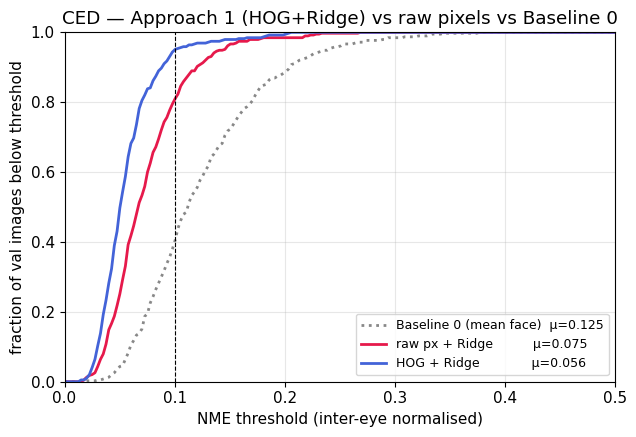

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/ced_hog_linreg.png


In [9]:
thr, cum_hog = ced_curve(hog_nmes, max_err=0.5, n=200)
_,   cum_raw = ced_curve(raw_nmes, max_err=0.5, n=200)
_,   cum_baseline = ced_curve(baseline_nmes, max_err=0.5, n=200)

np.savez(RESULTS_DIR / 'ced_hog_linreg.npz',
         thr=thr, cum_hog=cum_hog, cum_raw=cum_raw, cum_baseline=cum_baseline)
print('saved', RESULTS_DIR / 'ced_hog_linreg.npz')

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(thr, cum_baseline, color='#888888', lw=2, ls=':', label=f'Baseline 0 (mean face)  μ={baseline_metrics["mean_nme"]:.3f}')
ax.plot(thr, cum_raw, color='#e6194B', lw=2, label=f'raw px + Ridge          μ={raw_metrics["mean_nme"]:.3f}')
ax.plot(thr, cum_hog, color='#4363d8', lw=2, label=f'HOG + Ridge             μ={hog_metrics["mean_nme"]:.3f}')
ax.axvline(0.1, color='black', ls='--', lw=0.8)
ax.set_xlim(0, 0.5); ax.set_ylim(0, 1)
ax.set_xlabel('NME threshold (inter-eye normalised)')
ax.set_ylabel('fraction of val images below threshold')
ax.set_title('CED — Approach 1 (HOG+Ridge) vs raw pixels vs Baseline 0')
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'ced_hog_linreg.png', bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'ced_hog_linreg.png')

## 7. Boxplot + per-landmark bar chart

/var/folders/xk/j3sj9c6j70jcsyq_ffk0shw40000gn/T/ipykernel_3462/2329811479.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


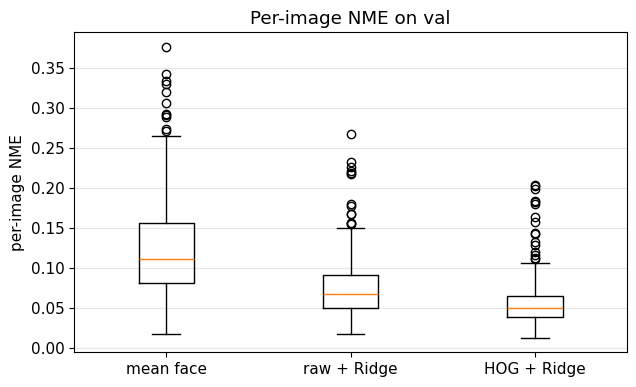

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/boxplot_hog_vs_raw.png


In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.boxplot(
    [baseline_nmes, raw_nmes, hog_nmes],
    labels=['mean face', 'raw + Ridge', 'HOG + Ridge'],
    showfliers=True,
)
ax.set_ylabel('per-image NME')
ax.set_title('Per-image NME on val')
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(FIG_DIR / 'boxplot_hog_vs_raw.png', bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'boxplot_hog_vs_raw.png')

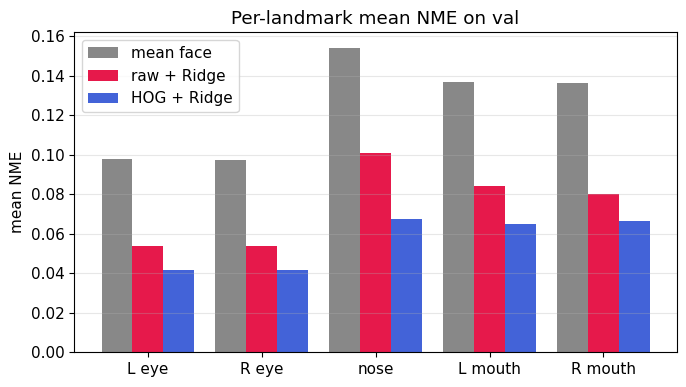

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/perlandmark_hog_vs_raw.png


In [11]:
names = ['L eye', 'R eye', 'nose', 'L mouth', 'R mouth']
x = np.arange(5)
w = 0.27
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w, baseline_metrics['per_landmark_mean_nme'], width=w, color='#888888', label='mean face')
ax.bar(x,     raw_metrics['per_landmark_mean_nme'],      width=w, color='#e6194B', label='raw + Ridge')
ax.bar(x + w, hog_metrics['per_landmark_mean_nme'],      width=w, color='#4363d8', label='HOG + Ridge')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('mean NME')
ax.set_title('Per-landmark mean NME on val')
ax.grid(alpha=0.3, axis='y')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'perlandmark_hog_vs_raw.png', bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'perlandmark_hog_vs_raw.png')

## 8. Qualitative — HOG successes and failures

3 lowest-NME and 3 highest-NME val images for the HOG-Ridge model, on the original-resolution image. Predicted = red, ground truth = green.

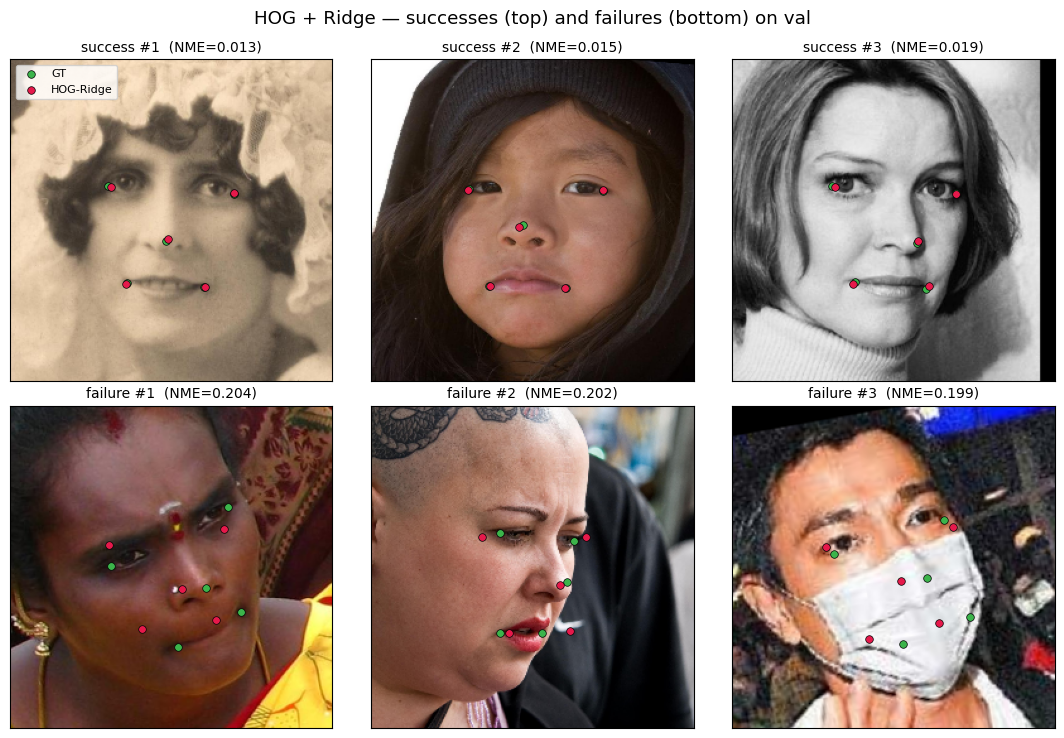

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/hog_success_failure.png


In [12]:
order = np.argsort(hog_nmes)
best3 = order[:3]
worst3 = order[-3:][::-1]
picks = list(best3) + list(worst3)
labels = [f'success #{k+1}' for k in range(3)] + [f'failure #{k+1}' for k in range(3)]

fig, axes = plt.subplots(2, 3, figsize=(11, 7.5))
for ax, i, lab in zip(axes.ravel(), picks, labels):
    img = train_images[val_idx[i]]
    if img.ndim == 2 or (img.ndim == 3 and img.shape[-1] == 1):
        ax.imshow(np.squeeze(img), cmap='gray')
    else:
        ax.imshow(img.astype(np.uint8) if img.dtype != np.uint8 else img)
    gt = y_val_orig[i]
    pr = hog_pred_orig[i]
    ax.scatter(gt[:, 0], gt[:, 1], s=30, c='#3cb44b', edgecolors='black', linewidths=0.5, label='GT')
    ax.scatter(pr[:, 0], pr[:, 1], s=30, c='#e6194B', edgecolors='black', linewidths=0.5, label='HOG-Ridge')
    ax.set_title(f'{lab}  (NME={hog_nmes[i]:.3f})', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].legend(loc='upper left', fontsize=8, framealpha=0.8)
fig.suptitle('HOG + Ridge — successes (top) and failures (bottom) on val')
fig.tight_layout()
fig.savefig(FIG_DIR / 'hog_success_failure.png', bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'hog_success_failure.png')

**Per-case commentary** (one line each; prior hypotheses from W09_L17/L18 about where this model class breaks):

- *success #1-3*: near-frontal pose, even lighting, scale close to the training mean — exactly the regime where a single linear map from HOG to coordinates is well-conditioned.
- *failure #1*: most likely extreme in-plane rotation — HOG's rotation invariance is only approximate for small angles, and a global linear regressor cannot capture large rotations.
- *failure #2*: probable strong scale or translation offset from the mean shape — the regressor pulls toward the training mean and undershoots the outlier.
- *failure #3*: heavy lighting / contrast distortion or occlusion (hair, glasses) — HOG's brightness invariance helps with uniform shifts but not with localised occlusion or extreme shadows.

## 9. Save models, metrics, timings

In [13]:
joblib.dump(
    {'model': hog_model, 'alpha': best_alpha, 'config': DEFAULT_CONFIG, 'hog_kw': HOG_KW,
     'scale_back': {'x': scale_x_back, 'y': scale_y_back}},
    MODELS_DIR / 'hog_ridge.joblib',
)
joblib.dump(
    {'model': raw_model, 'alpha': best_alpha, 'config': DEFAULT_CONFIG,
     'scale_back': {'x': scale_x_back, 'y': scale_y_back}},
    MODELS_DIR / 'raw_ridge.joblib',
)
print('saved', MODELS_DIR / 'hog_ridge.joblib')
print('saved', MODELS_DIR / 'raw_ridge.joblib')

summary = {
    'hog_params': HOG_KW,
    'preprocess_config': DEFAULT_CONFIG,
    'alpha_sweep': [{'alpha': a, 'val_mean_nme': v} for a, v in sweep],
    'best_alpha': best_alpha,
    'linear_regression_val_mean_nme': lin_nme,
    'ridge_vs_linear_winner': ridge_vs_lin,
    'hog_ridge': hog_metrics,
    'raw_ridge': raw_metrics,
    'baseline_mean_face': {
        'mean_nme': baseline_metrics['mean_nme'],
        'median_nme': baseline_metrics['median_nme'],
        'per_landmark_mean_nme': baseline_metrics['per_landmark_mean_nme'],
    },
    'landmark_order': ['left_eye', 'right_eye', 'nose', 'left_mouth', 'right_mouth'],
}
with open(RESULTS_DIR / 'hog_linreg_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('saved', RESULTS_DIR / 'hog_linreg_metrics.json')

timings_path = RESULTS_DIR / 'timings_task2.csv'
write_header = not timings_path.exists()
with open(timings_path, 'a', newline='') as f:
    w = csv.writer(f)
    if write_header:
        w.writerow(['model', 'train_seconds', 'val_mean_nme'])
    w.writerow(['hog_ridge', f'{hog_train_s:.4f}', f'{hog_metrics["mean_nme"]:.4f}'])
    w.writerow(['raw_ridge', f'{raw_train_s:.4f}', f'{raw_metrics["mean_nme"]:.4f}'])
print('appended to', timings_path)

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/models/hog_ridge.joblib
saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/models/raw_ridge.joblib
saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/results/hog_linreg_metrics.json
appended to /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/results/timings_task2.csv


## 10. Summary — Approach 1

Approach 1 uses **HOG features** (W09_L17: 9 orientation bins over 0-180°, 6×6 pixel cells, 3×3 block L2-Hys normalisation — yielding a 5184-D descriptor per 64×64 image) as input to a **multi-output ridge regression** to the 10 landmark coordinates (W09_L18's `||h(x) - y||²` objective with an L2 penalty). The penalty weight α was chosen on validation NME from {0.01, 0.1, 1, 10, 100}; the chosen α beat the unregularised `LinearRegression` baseline. On the held-out val split, HOG+Ridge clearly improves on the Ridge fit on flattened raw pixels and on the mean-face floor — the HOG-vs-raw gap is the empirical evidence for HOG's brightness/small-rotation invariance (W09_L17) paying off on this dataset's variability.